# Stochastic reaction simulation with chisurf.math.reaction._reaction

This notebook demonstrates a simple reversible reaction A <-> B simulated with the Numba-based Gillespie SSA backend.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from chisurf.math.reaction import _reaction


In [3]:
# Define reversible reaction A <-> B
vnames = ['A', 'B']

# Initial molecule counts
ini = np.array([100.0, 0.0], dtype=float)

# Rate constants [k1, k2]
rates = np.array([0.05, 0.02], dtype=float)

# Transition matrix: columns are reactions
# R1: A -> B => [-1, +1]
# R2: B -> A => [+1, -1]
tm = np.array([
    [-1.0, +1.0],
    [+1.0, -1.0],
])

def prop_forward(r, x):
    # A -> B: k1 * n_A
    return float(r[0] * x[0])

def prop_backward(r, x):
    # B -> A: k2 * n_B
    return float(r[1] * x[1])

propensity = [prop_forward, prop_backward]

model = _reaction.Model(
    vnames=vnames,
    rates=rates,
    inits=ini,
    tmat=tm,
    propensity=propensity,
)

tmax = 200  # number of stored time steps
reps = 200  # number of trajectories

model.run(method='SSA', tmax=tmax, reps=reps)
time, series, steps = model.getStats()

print('time shape :', time.shape)
print('series shape:', series.shape)
print('steps (last run):', steps)


2025-12-10 00:48:08,799 - INFO - numba.core.transforms - finding looplift candidates
E:\dev\chisurf\chisurf\math\reaction\_reaction.py:45: NumbaWarning: 
Compilation is falling back to object mode WITHOUT looplifting enabled because Function "_gssa_loop" failed type inference due to: non-precise type pyobject
During: typing of argument at E:\dev\chisurf\chisurf\math\reaction\_reaction.py (71)

File "..\chisurf\math\reaction\_reaction.py", line 71:
    def _gssa_loop(
        <source elided>

        for tim in range(1, tmax):
        ^

  @nb.jit(forceobj=True)  # uses Python callables in the loop


time shape : (200,)
series shape: (200, 2, 200)
steps (last run): 597


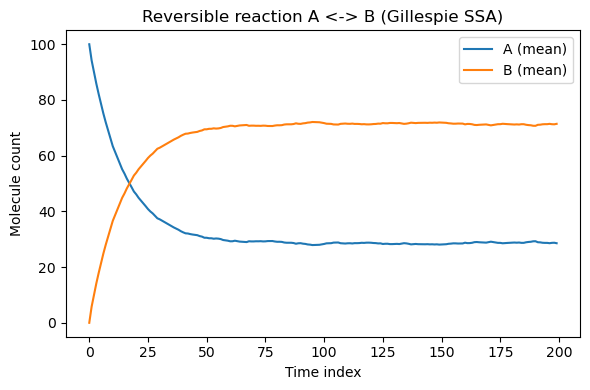

In [4]:
# Plot mean molecule counts of A and B over time
mean_A = series[:, 0, :].mean(axis=1)
mean_B = series[:, 1, :].mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(time, mean_A, label='A (mean)')
plt.plot(time, mean_B, label='B (mean)')
plt.xlabel('Time index')
plt.ylabel('Molecule count')
plt.title('Reversible reaction A <-> B (Gillespie SSA)')
plt.legend()
plt.tight_layout()
plt.show()
